# Function 6 Analysis - Week 1

This notebook contains the exploratory analysis for **Function 6** in Week 1. We examine the initial datapoints to understand the relationship between inputs (x1, x2, x3, x4, x5) and the output (y), then use Bayesian optimization to find promising regions for further exploration.

**Function Description:** You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design. To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sum.


## Loading and Displaying the Data

We load the initial inputs and outputs for function 6 and display them in a table format to inspect the raw data values.


In [32]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_6")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")
df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,x5,y
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
5,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049
6,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786
7,0.945069,0.288459,0.978806,0.961656,0.598016,-1.694343
8,0.125720,0.862725,0.028544,0.246605,0.751206,-2.571170
9,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116


df sorted by y


,x1,x2,x3,x4,x5,y,x_avg
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265,0.577357
1,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237,0.473535
2,0.782880,0.536336,0.443284,0.859700,0.010326,-0.935757,0.655550
3,0.536797,0.308781,0.411879,0.388225,0.522528,-1.144785,0.411421
4,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955,0.585829
5,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786,0.666097
6,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049,0.840746
7,0.432166,0.715618,0.341819,0.705000,0.614962,-1.294247,0.548651
8,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116,0.391039
9,0.021735,0.428084,0.835939,0.489489,0.511082,-1.356682,0.443812


## Correlation Matrix

The correlation heatmap shows pairwise correlations between all variables (x1, x2, x3, x4, x5, and y). Individual correlations with y are relatively low, except for x4 (+0.53) and x5 (-0.58). 


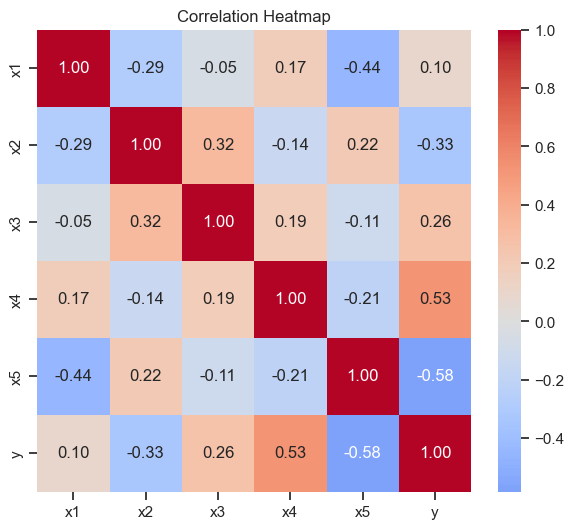

In [33]:
plt.figure(figsize=(7, 6))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## Pairplot Analysis

The pairplot provides a comprehensive view of pairwise relationships between all variables. The diagonal shows distributions (histograms), while off-diagonal plots show scatter plots. This helps identify patterns, clusters, and potential non-linear relationships that might not be captured by correlation alone.


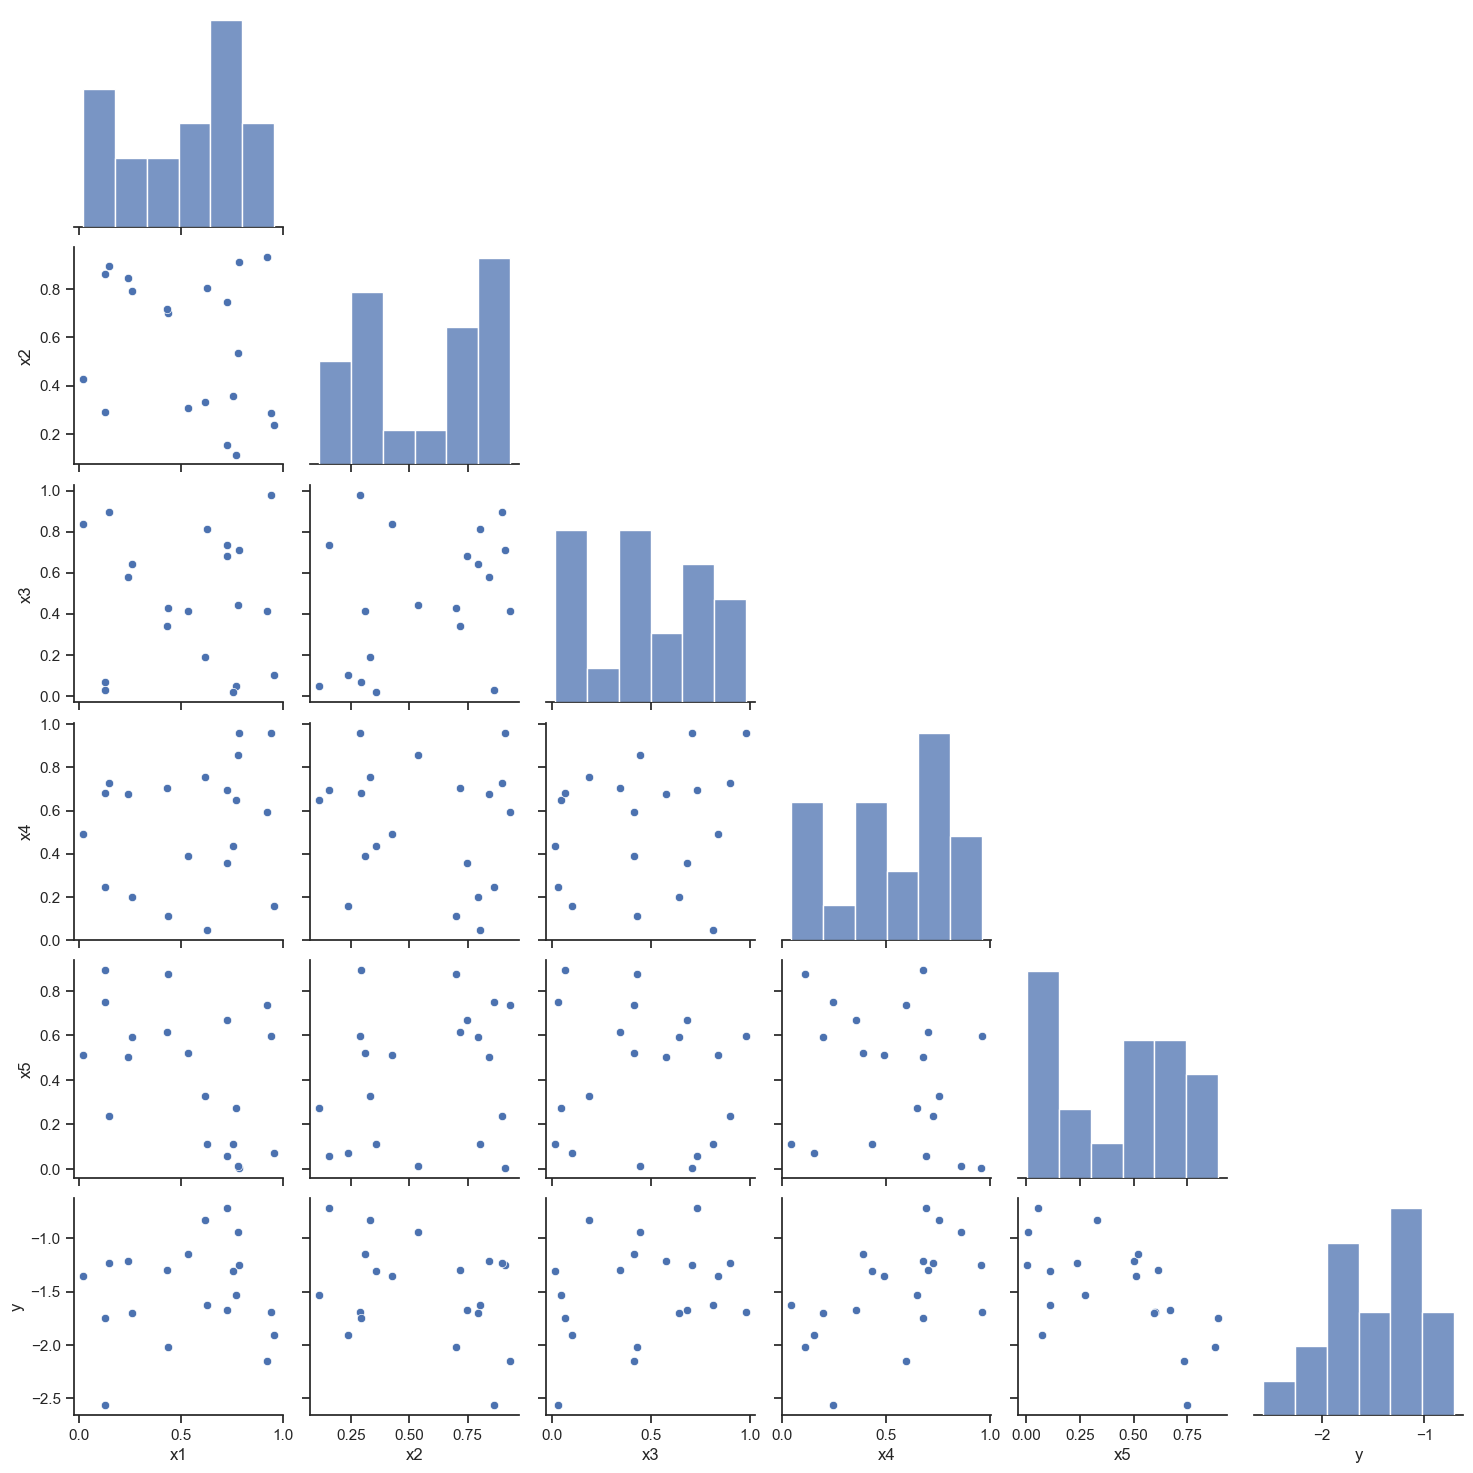

In [34]:
sns.pairplot(df, corner=True, diag_kind="hist")
plt.show()


## Conclusion from Exploratory Analysis

From the correlation matrix and pairplot, we observe that there are no obvious strong linear correlations between the input variables and the output. This suggests the function has complex, non-linear relationships or interactions between the five ingredient inputs, with some ingredients presumably interacting with each other. Given this complexity, Bayesian optimization is well-suited as it can model non-linear relationships and balance exploration of unknown regions with exploitation of promising areas.


## Bayesian Optimization Setup

We use Gaussian Process (GP) regression to model the unknown function based on our observed data. The GP provides both a mean prediction and uncertainty estimates. We use the Upper Confidence Bound (UCB) acquisition function to balance exploration (high uncertainty) and exploitation (high predicted mean). The search space is defined as [0, 1] for each of the five input variables. In our initial trial, we got a warning that "The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05" We believe that this may be due to noise (after all, it is human experts judging). We therefore included a WhiteKernel to account for that noise and reduce overfitting. We also used different lengthscales for each feature as different ingredients likely have different effects, we have 20 observations for 5 dimensions (enough to estimate 5 lengthscales reasonably) and the different lengthscales give us interpretability. We also tightened the bounds on each lengthscale as initial attempts showed wiggliness in some ingredients that could reflect overfitting. From the kernel parameters we can learn the following: 1/ in terms of Feature importance, x1 is the most influential ingredient with the smallest lengthscale (0.73), while the others have lengthscales of 1.9-2.7. The function is reasonably smooth across all dimensions (no extreme wiggles), and the noise level of 0.026 suggests the expert is fairly consistent. 


In [35]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from scipy.optimize import minimize
np.random.seed(42)
kernel = (
    Matern(
        length_scale=[1.0, 1.0, 1.0, 1.0, 1.0],
        length_scale_bounds=(0.1, 10.0),  # Reasonable range
        nu=2.5
    )
    + WhiteKernel(
        noise_level=0.1,
        noise_level_bounds=(0.01, 1.0)  # Force some noise
    )
)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gp.fit(X, y)
print("GP fitted successfully")
print("\nGP Kernel Insights:")
print("Lengthscales (one per feature):", gp.kernel_.k1.length_scale)
print("Noise level:", gp.kernel_.k2.noise_level)
print("Full kernel parameters:", gp.kernel_.get_params())


GP fitted successfully

GP Kernel Insights:
Lengthscales (one per feature): [0.73301294 2.66829226 2.60228044 1.94224455 2.4195718 ]
Noise level: 0.026071665965869233
Full kernel parameters: {'k1': Matern(length_scale=[0.733, 2.67, 2.6, 1.94, 2.42], nu=2.5), 'k2': WhiteKernel(noise_level=0.0261), 'k1__length_scale': array([0.73301294, 2.66829226, 2.60228044, 1.94224455, 2.4195718 ]), 'k1__length_scale_bounds': (0.1, 10.0), 'k1__nu': 2.5, 'k2__noise_level': np.float64(0.026071665965869233), 'k2__noise_level_bounds': (0.01, 1.0)}


## Finding the Next Point to Evaluate

We optimize the Upper Confidence Bound (UCB) acquisition function: UCB(x) = μ(x) + κ·σ(x), where μ(x) is the predicted mean, σ(x) is the predicted standard deviation, and κ is a parameter controlling the exploration-exploitation trade-off. A higher κ favors exploration, while a lower κ favors exploitation. We use κ=2.0 to balance both objectives.


In [36]:
kappa = 2.0
def ucb(x):
    x = x.reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    return -(mu + kappa * sigma)
bounds = [(0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]
result = minimize(ucb, x0=np.random.uniform(0, 1, 5), bounds=bounds, method='L-BFGS-B')
next_point = result.x
mu_pred, sigma_pred = gp.predict(next_point.reshape(1, -1), return_std=True)
print(f"Next point to evaluate: x1={next_point[0]:.4f}, x2={next_point[1]:.4f}, x3={next_point[2]:.4f}, x4={next_point[3]:.4f}, x5={next_point[4]:.4f}")
print(f"Predicted output: {mu_pred[0]:.4f} ± {sigma_pred[0]:.4f}")
print(f"UCB value: {mu_pred[0] + kappa * sigma_pred[0]:.4f}")


Next point to evaluate: x1=0.3859, x2=0.0000, x3=1.0000, x4=1.0000, x5=0.0000
Predicted output: -0.1251 ± 0.3683
UCB value: 0.6115


## Distance Analysis of Recommended Point

We calculate the Euclidean distance from the recommended point to all existing observations. This helps us understand how similar the recommended point is to our existing data. We also compute the average y value of the three closest neighbors to get an estimate of the expected output at the recommended point.


In [37]:
distances = np.sqrt(((X - next_point)**2).sum(axis=1))
df_dist = pd.DataFrame({"point_index": range(len(X)), "distance": distances, "y": y})
df_dist = df_dist.sort_values("distance")
print("Euclidean distances from recommended point to all observations:")
print(df_dist.to_string(index=False))
closest_3 = df_dist.head(3)
avg_y = closest_3["y"].mean()
print(f"\nThree closest neighbors: points {closest_3['point_index'].tolist()}")
print(f"Average y value of closest 3 neighbors: {avg_y:.4f}")


Euclidean distances from recommended point to all observations:
 point_index  distance         y
           0  0.556250 -0.714265
           7  0.869128 -1.694343
          17  0.880310 -0.935757
          13  0.929860 -1.356682
           4  0.996182 -0.829237
           6  1.001768 -1.233786
           5  1.037036 -1.247049
          10  1.054180 -1.144785
           1  1.125318 -1.209955
           3  1.126146 -1.536058
          16  1.188550 -1.294247
           9  1.250895 -1.309116
           2  1.282419 -1.672200
          12  1.289758 -1.622839
          15  1.330882 -1.702558
          11  1.382065 -1.912677
          19  1.387974 -1.746882
          18  1.484252 -2.155768
          14  1.543892 -2.018425
           8  1.699307 -2.571170

Three closest neighbors: points [0, 7, 17]
Average y value of closest 3 neighbors: -1.1148


## Analysis and recommendation
As expected, ingredients in a cake recipe follow a complex pattern where features interact with each other. We trained a Gaussian Process but had to make some adjustments to the settings we used previously. In particular, we had to use a WhiteKernel for noise and we decided to have different lengthscales for each feature in order to learn from the output. Unfortunately, the recommended point, which was purely mathematically driven, suggested points at the extremes (x1=0.3859, x2=0.0000, x3=1.0000, x4=1.0000, x5=0.0000), which in our view makes little sense as a value of 0 indicates the ingredient is missing completely (while this is possible in theory for sugar, it is less imaginable for flour, for example). We decided to override the extreme values picked by the Bayesian Optimisation, clipping them to more reasonable numbers: x1=0.3859, x2=0.1000, x3=0.9000, x4=0.9000, x5=0.1000